In [ ]:
# %% [Cell 1] Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [ ]:
df = pd.read_csv("/content/amazon_review.csv")   # update path if needed in Colab
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


In [ ]:
print("Rows, Columns:", df.shape)
print("\nColumn names:\n", list(df.columns))
print("\nData types:\n", df.dtypes)

Rows, Columns: (4915, 12)

Column names:
 ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime', 'day_diff', 'helpful_yes', 'total_vote']

Data types:
 reviewerID         object
asin               object
reviewerName       object
helpful            object
reviewText         object
overall           float64
summary            object
unixReviewTime      int64
reviewTime         object
day_diff            int64
helpful_yes         int64
total_vote          int64
dtype: object


In [ ]:
print(df.columns.tolist())

['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime', 'day_diff', 'helpful_yes', 'total_vote']


In [ ]:
print(df.head())
print(df.tail())

       reviewerID        asin  reviewerName helpful  \
0  A3SBTW3WS4IQSN  B007WTAJTO           NaN  [0, 0]   
1  A18K1ODH1I2MVB  B007WTAJTO          0mie  [0, 0]   
2  A2FII3I2MBMUIA  B007WTAJTO           1K3  [0, 0]   
3   A3H99DFEG68SR  B007WTAJTO           1m2  [0, 0]   
4  A375ZM4U047O79  B007WTAJTO  2&amp;1/2Men  [0, 0]   

                                          reviewText  overall  \
0                                         No issues.      4.0   
1  Purchased this for my device, it worked as adv...      5.0   
2  it works as expected. I should have sprung for...      4.0   
3  This think has worked out great.Had a diff. br...      5.0   
4  Bought it with Retail Packaging, arrived legit...      5.0   

                                  summary  unixReviewTime  reviewTime  \
0                              Four Stars      1406073600  2014-07-23   
1                           MOAR SPACE!!!      1382659200  2013-10-25   
2               nothing to really say....      1356220800  

In [ ]:
df.describe(include='all')

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
count,4915,4915,4914,4915,4914,4915.000000,4915,4.915000e+03,4915,4915.000000,4915.000000,4915.000000
unique,4915,1,4594,42,4912,NaN,3885,NaN,690,NaN,NaN,NaN
top,A8KGFTFQ86IBR,B007WTAJTO,Amazon Customer,"[0, 0]",Works fine my Virgin Mobile HTC EVO V. The pho...,NaN,Five Stars,NaN,2013-12-30,NaN,NaN,NaN
freq,1,4915,121,4360,2,NaN,46,NaN,26,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,4.587589,NaN,1.379465e+09,NaN,437.367040,1.311089,1.521465
std,NaN,NaN,NaN,NaN,NaN,0.996845,NaN,1.581857e+07,NaN,209.439871,41.619161,44.123095
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1.339200e+09,NaN,1.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,1.365898e+09,NaN,281.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,1.381277e+09,NaN,431.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,1.392163e+09,NaN,601.000000,0.000000,0.000000


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_percent': missing_pct})

,missing_count,missing_percent
reviewerID,0,0.00
asin,0,0.00
reviewerName,1,0.02
helpful,0,0.00
reviewText,1,0.02
overall,0,0.00
summary,0,0.00
unixReviewTime,0,0.00
reviewTime,0,0.00
day_diff,0,0.00


In [ ]:
print("Fully duplicate rows:", df.duplicated().sum())
print("Duplicate reviewText values:", df['reviewText'].duplicated().sum())
print("Duplicate (reviewerID + reviewText) pairs:",
      df.duplicated(subset=['reviewerID', 'reviewText']).sum())

Fully duplicate rows: 0
Duplicate reviewText values: 2
Duplicate (reviewerID + reviewText) pairs: 0


In [ ]:
for col in ['reviewerID', 'asin', 'reviewerName', 'helpful', 'overall', 'summary', 'reviewTime']:
    print(f"{col}: {df[col].nunique()} unique values")

reviewerID: 4915 unique values
asin: 1 unique values
reviewerName: 4594 unique values
helpful: 42 unique values
overall: 5 unique values
summary: 3885 unique values
reviewTime: 690 unique values


In [ ]:
def check_helpful_match(row):
    try:
        h = ast.literal_eval(row['helpful'])
        return h[0] == row['helpful_yes'] and h[1] == row['total_vote']
    except Exception:
        return None

matches = df.apply(check_helpful_match, axis=1)
print("Rows where 'helpful' column matches helpful_yes/total_vote:", matches.sum(), "out of", len(df))

Rows where 'helpful' column matches helpful_yes/total_vote: 4915 out of 4915


In [ ]:
print(df['overall'].value_counts().sort_index())
print((df['overall'].value_counts(normalize=True).sort_index() * 100).round(2))

overall
1.0     244
2.0      80
3.0     142
4.0     527
5.0    3922
Name: count, dtype: int64
overall
1.0     4.96
2.0     1.63
3.0     2.89
4.0    10.72
5.0    79.80
Name: proportion, dtype: float64


/tmp/ipykernel_1050/385060117.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='overall', data=df, palette='viridis', order=sorted(df['overall'].unique()))


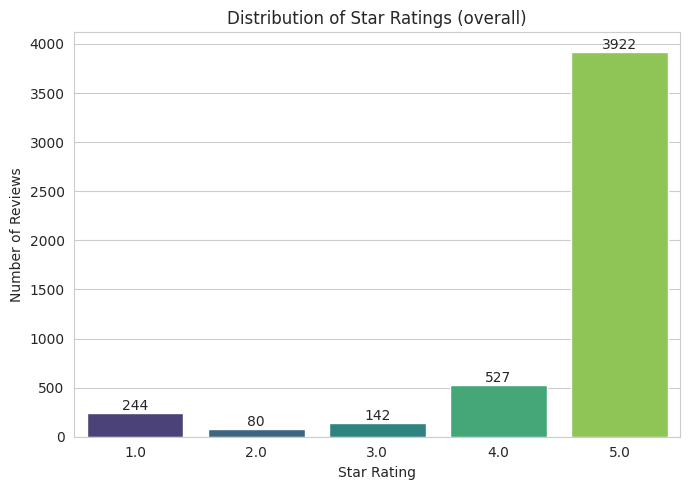

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='overall', data=df, palette='viridis', order=sorted(df['overall'].unique()))
plt.title("Distribution of Star Ratings (overall)")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [ ]:
df['review_char_count'] = df['reviewText'].fillna('').apply(len)
df['review_word_count'] = df['reviewText'].fillna('').apply(lambda x: len(str(x).split()))
df['summary_word_count'] = df['summary'].fillna('').apply(lambda x: len(str(x).split()))

df[['review_char_count', 'review_word_count', 'summary_word_count']].describe()

,review_char_count,review_word_count,summary_word_count
count,4915.000000,4915.000000,4915.000000
mean,267.692981,50.442319,4.385148
std,328.853307,59.114860,2.987830
min,0.000000,0.000000,1.000000
25%,123.000000,23.000000,2.000000
50%,172.000000,33.000000,4.000000
75%,289.000000,55.000000,6.000000
max,8638.000000,1554.000000,30.000000


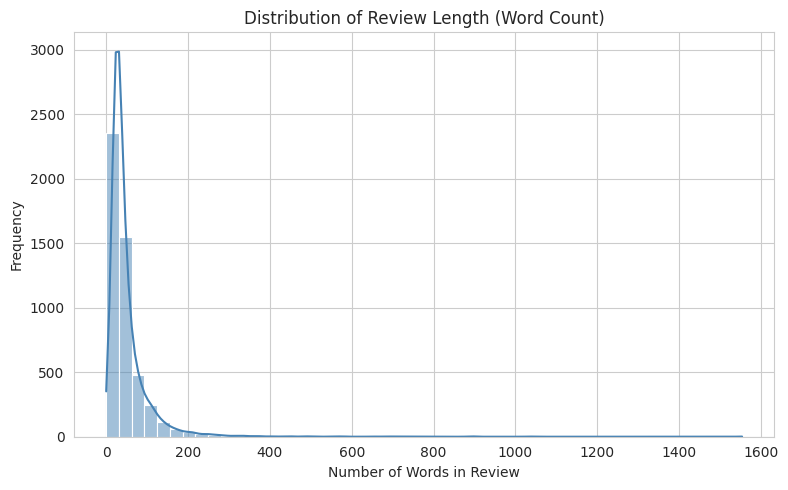

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['review_word_count'], bins=50, kde=True, color='steelblue')
plt.title("Distribution of Review Length (Word Count)")
plt.xlabel("Number of Words in Review")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

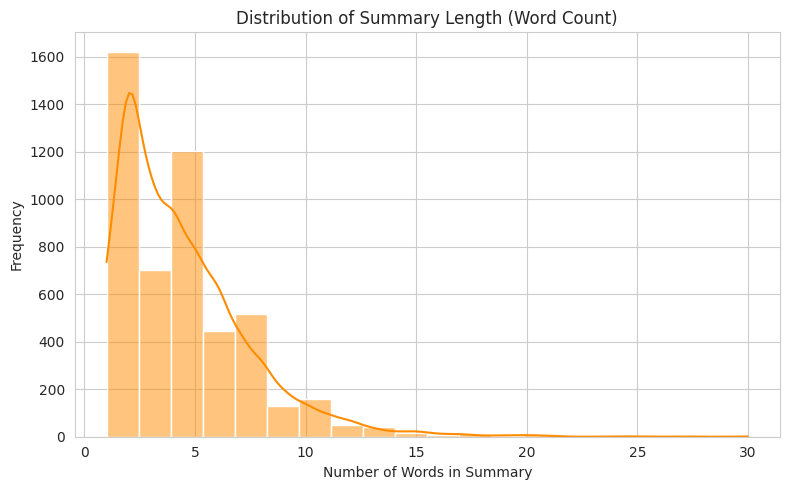

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['summary_word_count'], bins=20, kde=True, color='darkorange')
plt.title("Distribution of Summary Length (Word Count)")
plt.xlabel("Number of Words in Summary")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1050/1457678912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='overall', y='review_word_count', data=df, palette='coolwarm')


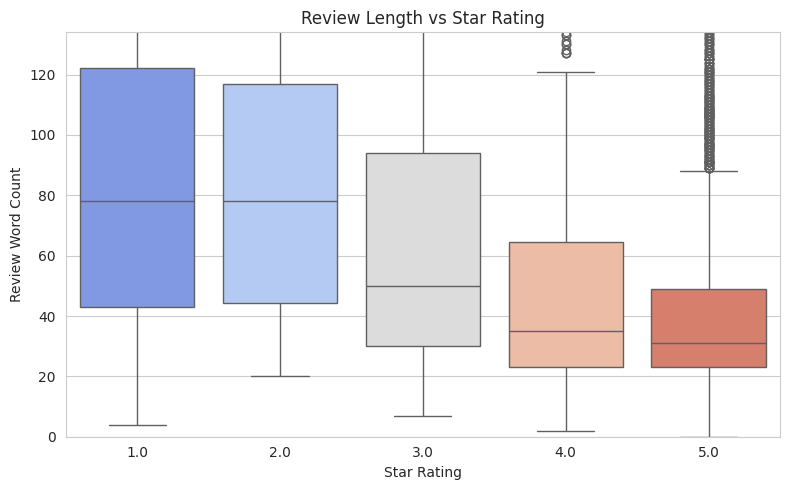

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='overall', y='review_word_count', data=df, palette='coolwarm')
plt.title("Review Length vs Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Review Word Count")
plt.ylim(0, df['review_word_count'].quantile(0.95))  # zoom in, exclude extreme outliers visually
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('overall')['review_word_count'].mean().round(2)

,review_word_count
overall,
1.0,103.86
2.0,114.48
3.0,73.25
4.0,56.21
5.0,44.21


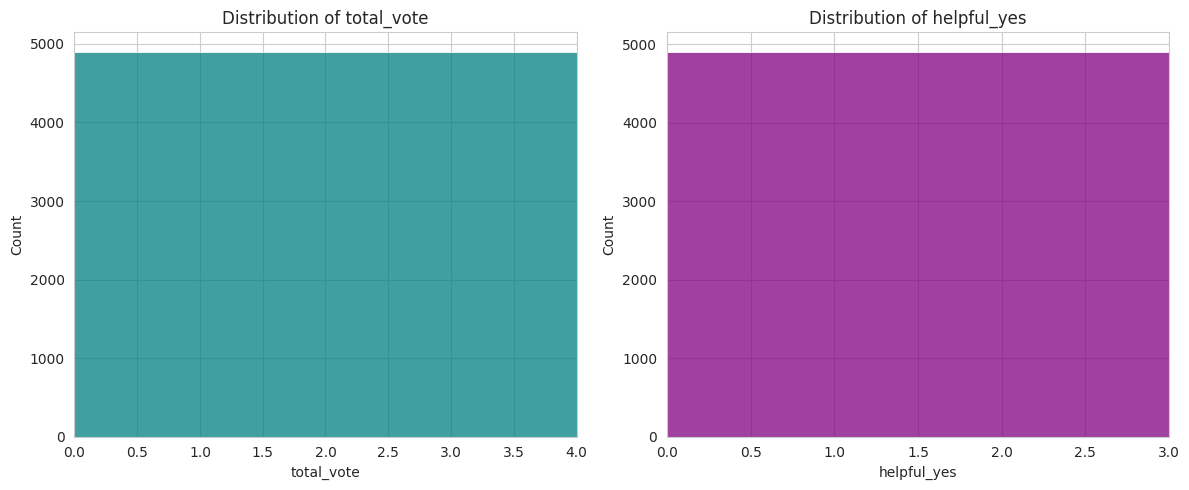

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['total_vote'], bins=50, ax=axes[0], color='teal')
axes[0].set_title("Distribution of total_vote")
axes[0].set_xlim(0, df['total_vote'].quantile(0.99))

sns.histplot(df['helpful_yes'], bins=50, ax=axes[1], color='purple')
axes[1].set_title("Distribution of helpful_yes")
axes[1].set_xlim(0, df['helpful_yes'].quantile(0.99))
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('overall')[['helpful_yes', 'total_vote']].mean().round(2)

,helpful_yes,total_vote
overall,,
1.0,8.97,10.40
2.0,0.24,0.54
3.0,0.35,0.54
4.0,0.21,0.61
5.0,1.04,1.15


/tmp/ipykernel_1050/2019621245.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='review_year', data=df, palette='crest')


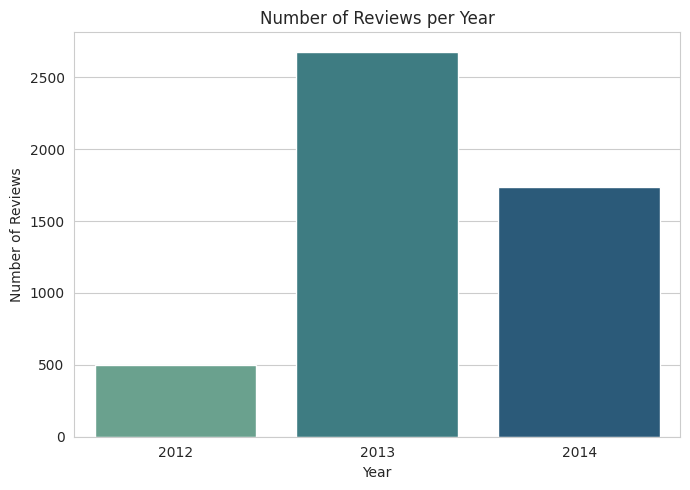

In [ ]:
df['reviewTime_parsed'] = pd.to_datetime(df['reviewTime'])
df['review_year'] = df['reviewTime_parsed'].dt.year

plt.figure(figsize=(7, 5))
sns.countplot(x='review_year', data=df, palette='crest')
plt.title("Number of Reviews per Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1050/2566476436.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=words_df, palette='mako')


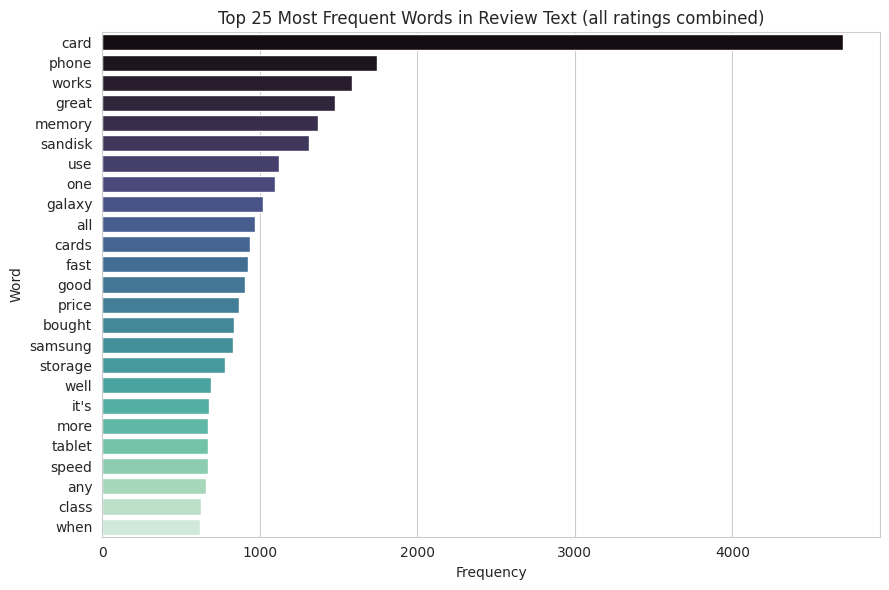

In [ ]:
from collections import Counter
import re

def get_words(text_series):
    words = []
    for t in text_series.fillna(''):
        tokens = re.findall(r"[a-zA-Z']+", str(t).lower())
        words.extend(tokens)
    return words

# Simple English stopword list (avoids needing internet / nltk download in Colab)
stopwords = set("""a an the this that these those is are was were be been being
i you he she it we they my your his her its our their me him them us
and or but if then so as of to in on at for with from by about into
have has had do does did not no nor can will would should could may might
just very s t re ve ll d m""".split())

all_words = get_words(df['reviewText'])
filtered_words = [w for w in all_words if w not in stopwords and len(w) > 2]
word_freq = Counter(filtered_words).most_common(25)

words_df = pd.DataFrame(word_freq, columns=['word', 'count'])
plt.figure(figsize=(9, 6))
sns.barplot(x='count', y='word', data=words_df, palette='mako')
plt.title("Top 25 Most Frequent Words in Review Text (all ratings combined)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1050/3101714171.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=high_freq, ax=axes[0], palette='Greens_r')
/tmp/ipykernel_1050/3101714171.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=low_freq, ax=axes[1], palette='Reds_r')


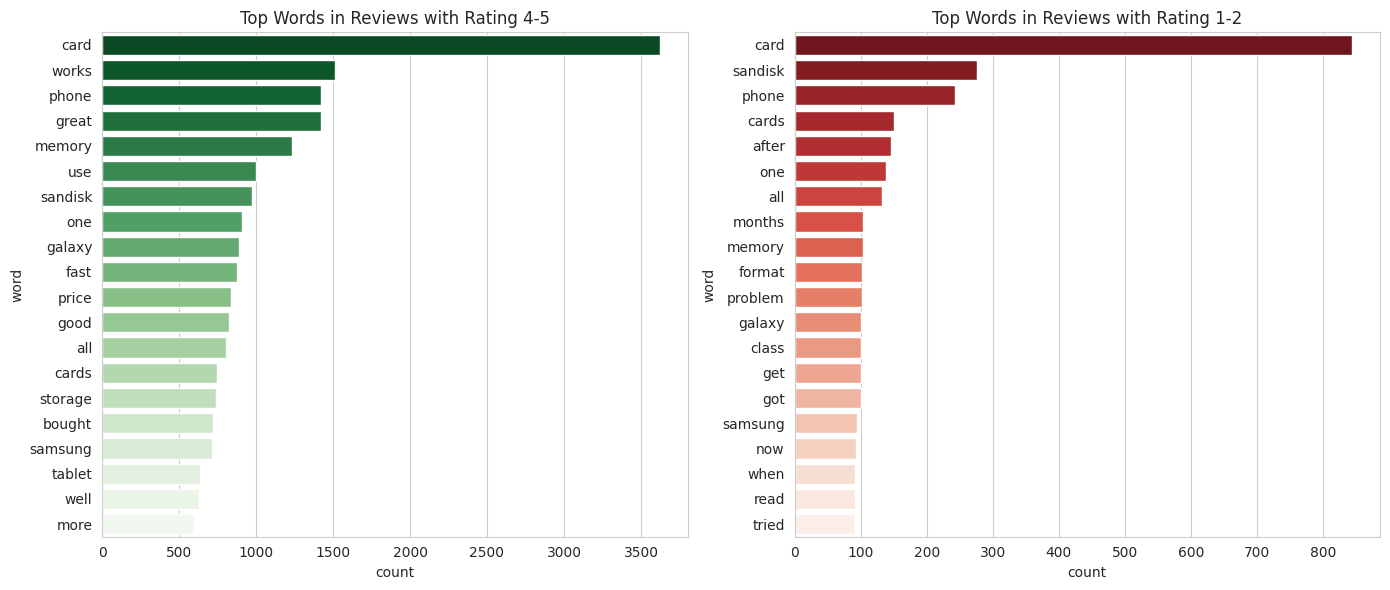

In [ ]:
high_rating_words = get_words(df.loc[df['overall'] >= 4, 'reviewText'])
low_rating_words  = get_words(df.loc[df['overall'] <= 2, 'reviewText'])

high_filtered = [w for w in high_rating_words if w not in stopwords and len(w) > 2]
low_filtered  = [w for w in low_rating_words  if w not in stopwords and len(w) > 2]

high_freq = pd.DataFrame(Counter(high_filtered).most_common(20), columns=['word', 'count'])
low_freq  = pd.DataFrame(Counter(low_filtered).most_common(20),  columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x='count', y='word', data=high_freq, ax=axes[0], palette='Greens_r')
axes[0].set_title("Top Words in Reviews with Rating 4-5")

sns.barplot(x='count', y='word', data=low_freq, ax=axes[1], palette='Reds_r')
axes[1].set_title("Top Words in Reviews with Rating 1-2")
plt.tight_layout()
plt.show()

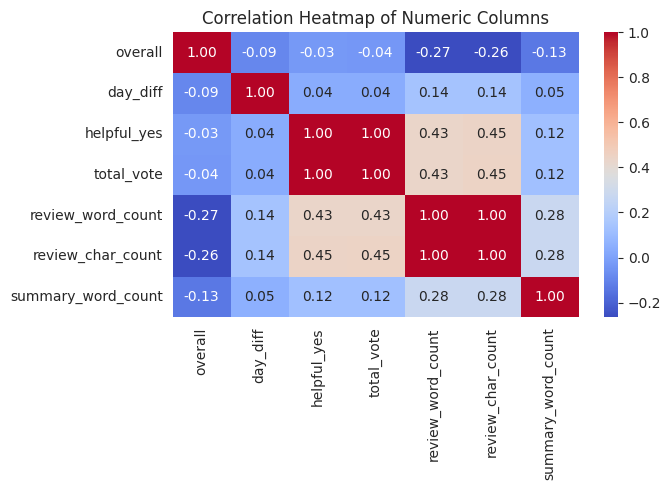

In [ ]:
plt.figure(figsize=(7, 5))
numeric_cols = ['overall', 'day_diff', 'helpful_yes', 'total_vote',
                 'review_word_count', 'review_char_count', 'summary_word_count']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Numeric Columns")
plt.tight_layout()
plt.show()